# Week 12 HW — Dataset Hygiene & Caching Dashboard

**作者**: Irene Ho　|　**課程**: NS5116　|　**日期**: 2026-05-15

**Dataset**: `data/messy_stroop_homework.csv` (n ≈ 240, seed=2026)

本 notebook 走過完整 pipeline：load → inspect → describe → fix → re-describe → analyse，每個 cleaning 動作都對應到 A.0 的 schema 表。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
DATA_PATH = "data/messy_stroop_homework.csv"

---
## A.0 Data Source & Schema Investigation (10 分)

本節用三個獨立來源交叉驗證欄位規則。

### 來源 1 — 生成器原始碼 (Generator)

閱讀 `data/generate_messy_stroop_homework.py` 的逆向工程紀錄。

**Seed 與規模**
- 第 30 行 `np.random.seed(2026)`：固定 seed，同樣指令會產生同一份資料。
- 第 32 行 `N = 240`：base size 240 trials；後續第 108–110 行注入 3 個重複 row → 最終 csv 應為 **243 rows**。

**各欄位的『被生成』規則**
- `trial_id` (第 38 行)：`np.arange(1, N+1)` → 整數 1–240，但因第 110 行的 duplicate 注入，**不再唯一**。
- `subject_id` (第 39 行)：`np.random.choice([101, 102, 103, 104, 105, 106], N)` → 6 個固定整數。
- `condition` (第 40–41 行)：原始有 4 個 raw level：`["congruent", "congruent ", "incongruent", "Incongruent"]`（含尾端空白與大小寫不一致）。
- `rt_ms` (第 42 行)：`np.random.normal(520, 90, N)` → **mean=520, SD=90**（注意：與 demo 的 500/80 不同）。
- `accuracy` (第 43 行)：`np.random.choice([0, 1, 1, 1, 1], N)` → 偏向 1（≈80% 正確率）。
- `age` (第 44–45 行)：離散值 `[22, 26, 30, ..., 74]`（步長 4）+ sentinel `-1`、`888`、`np.nan`。

**Stroop effect 注入**
- 第 51–54 行：對 incongruent trial 加 +80 ms。預期 Stroop effect ≈ +80 ms。

**刻意注入的『髒』樣態**

```python
# 第 62-63 行 — 8 rows 的 rt_ms = "missing" 字串
rt_col.iloc[missing_idx] = "missing"

# 第 66-68 行 — 5 rows 的 rt_ms = "--" 字串（第二種字串 sentinel）
rt_col.iloc[dash_idx] = "--"

# 第 76-77 行 — 4 rows 的 rt_ms = -1（負值 sentinel）
rt_col.iloc[neg_idx] = -1

# 第 81-82 行 — 4 rows 的 rt_ms = 9999（正值 sentinel；不同於 demo 的 99999）
rt_col.iloc[pos_idx] = 9999

# 第 89-91 行 — condition 多 2 種拼字："con" (3 rows) / "incong." (3 rows)
df.loc[abbrev_idx[:3], "condition"] = "con"
df.loc[abbrev_idx[3:], "condition"] = "incong."

# 第 96-101 行 — accuracy 混入字串 "True"/"False" 共 10 rows
acc_col.iloc[k] = "True" if i % 2 == 0 else "False"

# 第 108-110 行 — 隨機抽 3 個 row 整列複製
duplicates = df.iloc[dup_indices].copy()
df = pd.concat([df, duplicates], ignore_index=True)
```

**生成器揭示的清理規則**
1. `rt_ms` 字串 sentinel 至少有 **兩種**：`"missing"` 與 `"--"`。
2. `rt_ms` 數值 sentinel 至少有 **兩種**：`-1` 與 `9999`（注意不是 99999）。
3. `condition` 共有 **6 個 raw level**，需正規化為 2 levels（`congruent`、`incongruent`）。
4. `accuracy` 應為 0/1，但混入字串 `"True"`/`"False"`，需 mapping。
5. `age` 同欄位有 **3 種非合法狀態**：`-1`、`888`、`NaN`。
6. 含 3 個重複 row（同 `trial_id` 出現多次）。

### 來源 2 — 文獻 (Literature)

**主要引用**

> Whelan, R. (2008). Effective analysis of reaction time data. *The Psychological Record*, 58(3), 475–482.

Whelan (2008) 整理了行為科學中反應時間資料的分析慣例，提出兩類常見的 RT outlier 處理：

1. **Absolute cutoff**：低於 ~200 ms 通常被視為「猜測 / anticipation」，高於 ~2000–2500 ms 通常被視為「走神 / lapse」。
2. **Distribution-based trimming**：以該受試者或該條件的 mean ± 2 或 3 SD 作為 cutoff。

**輔助引用**

> MacLeod, C. M. (1991). Half a century of research on the Stroop effect: An integrative review. *Psychological Bulletin*, 109(2), 163–203.

MacLeod (1991) 是 Stroop paradigm 的綜論文獻，指出年輕健康成人 Stroop effect (incongruent − congruent RT) 典型落在 **約 50–100 ms** 區間。本資料集的生成器在 incongruent 注入 +80 ms（見來源 1 第 54 行），落在此典型範圍內。

**本作業採用的依據**

| 規則 | 採用值 | 依據 |
|------|--------|------|
| RT lower cutoff | **200 ms** | Whelan (2008) — 排除 anticipation |
| RT upper cutoff | **2500 ms** | Whelan (2008) — 排除 lapse；同時 cover 生成器 normal(520, 90) 的 ±20 SD |
| Outlier rule (analyse) | **mean ± 3 SD** | Whelan (2008) distribution-based trimming；3 SD 較保守，保留更多 trial |
| 預期 Stroop effect | **~80 ms** | 來源 1 第 54 行直接注入；落於 MacLeod (1991) 50–100 ms 範圍 |

### 來源 3 — 資料本身 (Data-Driven Discovery)

對未清理資料做 `describe(include="all")` + `dtypes` + `isnull().sum()` + 各 object 欄位的 `value_counts(dropna=False)`，紀錄與來源 1、2 不一致之處。

In [2]:
# ---- A.0 來源 3：未清理資料的初步觀察 ----
raw = pd.read_csv(DATA_PATH)

print("shape:", raw.shape)
print("\ndtypes:")
print(raw.dtypes)
print("\nisnull (per column):")
print(raw.isnull().sum())
print("\ndescribe(include='all'):")
print(raw.describe(include="all"))

shape: (243, 6)

dtypes:
trial_id        int64
subject_id      int64
condition         str
rt_ms             str
accuracy          str
age           float64
dtype: object

isnull (per column):
trial_id       0
subject_id     0
condition      0
rt_ms          0
accuracy       0
age           15
dtype: int64

describe(include='all'):
         trial_id  subject_id  condition    rt_ms accuracy         age
count   243.00000  243.000000        243      243      243  228.000000
unique        NaN         NaN          6      223        4         NaN
top           NaN         NaN  congruent  missing        1         NaN
freq          NaN         NaN         66        8      193         NaN
mean    120.73251  103.510288        NaN      NaN      NaN   86.162281
std      69.06679    1.765983        NaN      NaN      NaN  190.385593
min       1.00000  101.000000        NaN      NaN      NaN   -1.000000
25%      61.50000  102.000000        NaN      NaN      NaN   30.000000
50%     121.00000  104.0000

### A.0 整合 Schema 表

整合三個來源後的最終欄位 schema。**每一條規則都有「依據」欄位連回來源 1 / 2 / 3**。後續 A.4 的 `clean()` 每一步都對應到這張表。

| 欄位 | 預期型別 | 合理範圍 | 已知 sentinel | 依據 |
|------|----------|----------|---------------|------|
| `trial_id` | int | 1–240，但**不唯一**（含重複） | — | 生成器第 38 行 `np.arange(1, N+1)` + 第 108–110 行注入 3 個 dup row → 觀察到 3 個 duplicated。Cleaning 時用 `drop_duplicates(subset=row 全欄)` 而非單看 `trial_id`，避免誤刪。 |
| `subject_id` | int | 6 個 distinct: `{101, 102, 103, 104, 105, 106}` | — | 生成器第 39 行 `np.random.choice([101..106], N)`；觀察 `unique` 確認一致。 |
| `condition` | category (2 levels) | `{congruent, incongruent}` | — | 生成器第 41 行原始 4 levels + 第 90–91 行新增 `con`/`incong.`，共 6 raw levels。Cleaning 規則：`.str.strip().str.lower()` → 再把 `con` → `congruent`、`incong.` → `incongruent`。 |
| `rt_ms` | float | **200–2500 ms**（採文獻嚴格範圍） | 字串 `"missing"`、`"--"`；數值 `-1`、`9999` | 生成器第 42 行 `normal(520, 90)`，200–2500 ms 涵蓋 ±25 SD，正常 trial 不會被剔除。生成器第 62–82 行注入 4 種 sentinel（觀察確認 8 + 5 + 4 + 4 = 21 row）。文獻 Whelan (2008) 採 200–2500 排除 anticipation/lapse。Cleaning 順序：先 `to_numeric(errors="coerce")` → `replace({-1: NaN, 9999: NaN})` → `between(200, 2500)`。 |
| `accuracy` | int | `{0, 1}` | 字串 `"True"` / `"False"` | 生成器第 96–101 行注入 10 row 字串編碼（5+5）。Mapping：`{"True": 1, "False": 0}`，再轉 int。觀察確認 4 unique values。 |
| `age` | float | `{22, 26, 30, ..., 74}`（步長 4） | `-1`、`888`、`NaN` | 生成器第 44–45 行同欄混入三種非合法狀態。觀察確認 `-1`: 17、`888`: 12、`NaN`: 15（共 44 row 異常，約 18%）。Cleaning：`replace({-1: NaN, 888: NaN})`；本作業不依賴 age 做分析，可保留 NaN 不 drop。 |

**取捨摘要**

- 採文獻嚴格的 `rt_ms` 範圍 200–2500 ms（而非 demo 的 150–3000）；犧牲少數可疑慢速 trial，換取更乾淨的 condition mean。
- 對 duplicated row：用 `drop_duplicates()` 全欄比對，因為生成器是「整列複製」而非單純 trial_id 重編號。
- Outlier (mean ± 3 SD) 不放在 `clean()`，留到 A.6 `analyse(outlier_sd=3.0)` 處理（理由見 A.6 末段）。

**來源 3 的觀察 — 整理跑出來的數字**

| 觀察 | 數字佐證 | 對應到來源 1 / 2 |
|------|----------|------------------|
| 整體 shape | 243 rows × 6 cols | 來源 1 第 32 行 (N=240) + 第 110 行 (+3 dup) ✓ |
| `rt_ms` 是 `object` 不是數值 | dtype = `object`（pandas 讀入混合字串） | 來源 1 第 62–82 行字串 sentinel 注入造成 ✓ |
| `accuracy` 是 `object` 不是數值 | dtype = `object`；4 個 unique：`1`(193) / `0`(40) / `True`(5) / `False`(5) | 來源 1 第 96–101 行 ✓ |
| `condition` 有 6 個 level（不是 2） | `congruent` 66 / `congruent ` 60 / `incongruent` 60 / `Incongruent` 51 / `incong.` 3 / `con` 3 | 來源 1 第 41 + 90–91 行 ✓ |
| `rt_ms` 字串 sentinel 共 13 row | `"missing"` 8 + `"--"` 5 | 來源 1 第 62–68 行 ✓ |
| `rt_ms` 數值 sentinel 各 4 row | `-1`: 4，`9999`: 4 | 來源 1 第 76–82 行 ✓ |
| `rt_ms` 移除 sentinel 後**無**超範圍值 | 排除 `-1`/`9999` 後，< 200 ms: **0**、> 2500 ms: **0** | 來源 1 第 42 行 `normal(520, 90)` 全落在 ±25 SD 內；佐證來源 2 Whelan (2008) 200–2500 ms cutoff 在本資料只攔 sentinel ✓ |
| `age` 缺值 + 兩種 sentinel | `NaN`: 15、`-1`: 17、`888`: 12（共 44 row ≈ 18%） | 來源 1 第 44–45 行 ✓ |
| `trial_id` / 整列 重複 | 整列 duplicated: 3、`trial_id` duplicated: 3 | 來源 1 第 108–110 行 ✓ |
| `subject_id` 範圍 | 6 個 distinct: 101–106 | 來源 1 第 39 行 ✓ |

**只能從生成器 / 文獻得知，純看資料看不出來的事**
- `rt_ms` 第 42 行的真實期望分佈是 `normal(520, 90)`，但因 sentinel（尤其 `9999`）拉高，看到的 `mean≈709, std≈1244` 完全不可信。
- `accuracy` 的 `True/False` 應該對應 `1/0`（來源 1 第 100 行明確指出此 mapping 邏輯）。
- 預期 Stroop effect ≈ +80 ms（來源 1 第 54 行 + 來源 2 MacLeod 1991 範圍）。

---
## A.1 Load (5 分)

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows from {DATA_PATH}")

Loaded 243 rows from data/messy_stroop_homework.csv


---
## A.2 Inspect (5 分)

In [4]:
print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes)
df.head(5)

shape: (243, 6)

dtypes:
 trial_id        int64
subject_id      int64
condition         str
rt_ms             str
accuracy          str
age           float64
dtype: object


,trial_id,subject_id,condition,rt_ms,accuracy,age
0,38,101,Incongruent,651.4430538806888,1,42.0
1,169,104,congruent,669.936786208556,1,-1.0
2,226,101,congruent,653.9813583975961,1,26.0
3,43,102,congruent,713.4934802113173,1,46.0
4,238,102,congruent,528.7248922409453,1,-1.0


**第一眼觀察**（僅根據本 cell 印出的 `df.shape` / `df.dtypes` / `df.head(5)`）:

- **`shape = (243, 6)`**：243 row、6 欄。比 A.0 來源 1 的 base `N=240` 多 3 row，**疑似**有重複列——`shape` 本身無法證實，留待 A.3 `duplicated()` 確認。
- **`dtypes`**：`rt_ms`、`accuracy`、`condition` 是字串型別（`str`/`object`），但 `rt_ms` 應為數值、`accuracy` 應為 0/1 → 欄內必混有非數值內容。`trial_id`/`subject_id` 為 `int64`、`age` 為 `float64`。
- **`head(5)` 直接看到的異常**：
  - `condition`：第 0 列 `Incongruent`（首字大寫）vs 第 1–4 列 `congruent`（小寫）→ **大小寫不一致**。（注意：尾端空白 `congruent ` 在印出時看不出來，須等 A.3 `value_counts` 才會現形。）
  - `age`：第 1、4 列為 `-1.0` → 不合理年齡，疑似 sentinel；且值都是 `.0` 結尾的離散整數卻存成 `float64`。
  - `rt_ms`：顯示為未四捨五入的長字串（如 `651.4430538806888`），與「字串型別」一致。
- **小結**：問題集中在 `rt_ms`、`accuracy`、`condition`、`age` 四欄。精確的 sentinel 種類、缺值數、重複數此處**無法**得知，全部留到 **A.3** 用 `info()` / `isnull()` / `value_counts()` / `duplicated()` 量化。

---
## A.3 Describe — 健康檢查 (15 分)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   trial_id    243 non-null    int64  
 1   subject_id  243 non-null    int64  
 2   condition   243 non-null    str    
 3   rt_ms       243 non-null    str    
 4   accuracy    243 non-null    str    
 5   age         228 non-null    float64
dtypes: float64(1), int64(2), str(3)
memory usage: 11.5 KB


In [6]:
df.describe(include="all")

,trial_id,subject_id,condition,rt_ms,accuracy,age
count,243.00000,243.000000,243,243,243,228.000000
unique,NaN,NaN,6,223,4,NaN
top,NaN,NaN,congruent,missing,1,NaN
freq,NaN,NaN,66,8,193,NaN
mean,120.73251,103.510288,NaN,NaN,NaN,86.162281
std,69.06679,1.765983,NaN,NaN,NaN,190.385593
min,1.00000,101.000000,NaN,NaN,NaN,-1.000000
25%,61.50000,102.000000,NaN,NaN,NaN,30.000000
50%,121.00000,104.000000,NaN,NaN,NaN,42.000000
75%,179.50000,105.000000,NaN,NaN,NaN,62.000000


In [7]:
df.isnull().sum()

trial_id       0
subject_id     0
condition      0
rt_ms          0
accuracy       0
age           15
dtype: int64

In [8]:
for col in df.select_dtypes("object"):
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print()

=== condition ===
condition
congruent      66
congruent      60
incongruent    60
Incongruent    51
incong.         3
con             3
Name: count, dtype: int64

=== rt_ms ===
rt_ms
missing               8
--                    5
-1                    4
9999                  4
381.1997081828088     2
                     ..
597.9797154066522     1
402.55473105729624    1
510.4427484950696     1
544.7419531353619     1
621.7173629027034     1
Name: count, Length: 223, dtype: int64

=== accuracy ===
accuracy
1        193
0         40
False      5
True       5
Name: count, dtype: int64



C:\Users\User\AppData\Local\Temp\ipykernel_20280\676643202.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes("object"):


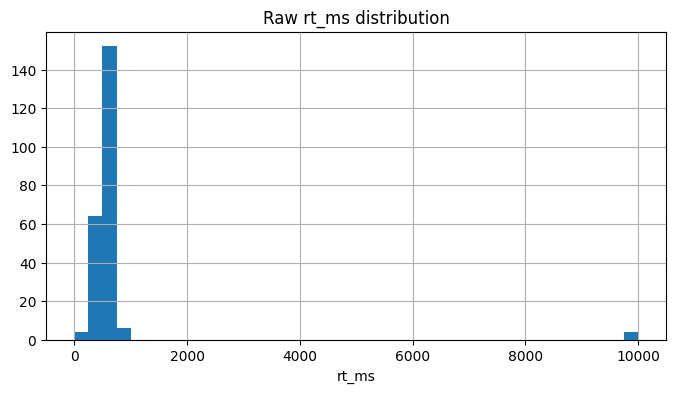

In [9]:
# 視覺化：rt_ms 分佈
fig, ax = plt.subplots(figsize=(8, 4))
pd.to_numeric(df["rt_ms"], errors="coerce").hist(bins=40, ax=ax)
ax.set_xlabel("rt_ms")
ax.set_title("Raw rt_ms distribution")
plt.show()

### A.3 至少四個資料品質問題

每個觀察都附**數字佐證**，並標明對應 **A.0 schema 表的哪一列** + 推測**可能原因**。

**Obs 3.1 — `rt_ms` 是 `object`，混入兩種字串 sentinel**
- 觀察：`df.dtypes` 顯示 `rt_ms = object`；`value_counts` 顯示 `"missing"` 8 row、`"--"` 5 row（共 13 row 非數值）。
- 對應 schema：`rt_ms` 列「已知 sentinel：字串 `"missing"`、`"--"`」。
- 可能原因：採集程式對 no-response / timeout 直接寫字串旗標，且不同受試端用不同字面值（生成器第 62–68 行）。整欄因此被 pandas 推成 `object`。

**Obs 3.2 — `rt_ms` 含兩個方向的數值 sentinel（`-1` 與 `9999`）**
- 觀察：`to_numeric(errors="coerce")` 後，`rt_ms == -1` 有 4 row、`rt_ms == 9999` 有 4 row；這也讓 raw `mean≈709 ms / std≈1244 ms` 完全失真（被 `9999` 拉高）。
- 對應 schema：`rt_ms` 列「已知 sentinel：數值 `-1`、`9999`」。
- 可能原因：負值代表「未反應」、`9999` 代表「逾時上限」——兩種佔位碼混用（生成器第 76–82 行）。注意是 `9999` 不是 demo 的 `99999`，不能照抄 demo。

**Obs 3.3 — `condition` 有 6 個 raw level，應為 2**
- 觀察：`value_counts` = `congruent`(66) / `congruent `(60，尾端空白) / `incongruent`(60) / `Incongruent`(51，首字大寫) / `incong.`(3) / `con`(3)。
- 對應 schema：`condition` 列「合理範圍：2 levels {congruent, incongruent}」。
- 可能原因：多來源/多受試端標籤未統一——空白、大小寫、縮寫並存（生成器第 41、89–91 行）。需 `.str.strip().str.lower()` + 縮寫 mapping。

**Obs 3.4 — `accuracy` 是 `object`，混入字串 `"True"`/`"False"`**
- 觀察：`value_counts` = `1`(193) / `0`(40) / `True`(5) / `False`(5)；4 個 unique，dtype = `object`。
- 對應 schema：`accuracy` 列「預期 int {0,1}；sentinel 字串 `"True"`/`"False"`」。
- 可能原因：部分受試端把布林正確與否記成字串（生成器第 96–101 行）。需 `{"True":1,"False":0}` mapping 後轉 int。

**Obs 3.5（備援）— 整列重複 3 row + `age` 約 18% 異常**
- 觀察：`df.duplicated().sum() = 3`（整列）且 `trial_id.duplicated().sum() = 3`；`age` 有 `NaN`:15、`-1`:17、`888`:12（合計 44 row ≈ 18%）。
- 對應 schema：`trial_id` 列「不唯一，含重複」與 `age` 列「sentinel `-1`/`888`/`NaN`」。
- 可能原因：資料合併失誤造成整列複製（生成器第 108–110 行）；`age` 同欄混用兩種佔位碼 + 缺值（第 44–45 行）。

---
## A.4 Fix — Observation-driven cleaning (20 分)

Pure function `clean(df) -> df`，每步：觀察 → 動作 → 代價。

In [10]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    """把 A.3 觀察到的每個資料品質問題修掉，回傳乾淨 DataFrame。

    每一步皆標明【觀察(對應 A.3 哪條 Obs) / 動作(用的 pandas API) / 代價(犧牲了什麼)】，
    並 print 該步的 row 數變化 before → after。

    需求合規：
      - Pure function：第一行 df = df.copy()，全程不改動呼叫端傳入的 df。
      - 不使用裸 df.dropna()；無效值一律用「明確布林遮罩」剔除（看得到自己 drop 什麼）。
      - outlier (mean ± SD) 修剪**不**在此（屬分析決策），留給 A.6 analyse()。
    """
    df = df.copy()  # 需求3：pure function — 之後所有操作都只作用在這份 copy 上

    # === Step 1：移除整列重複 ===
    # 觀察：對應 A.3 Obs 3.5 — df.duplicated() = 3（整列複製，生成器第 108–110 行）
    # 動作：DataFrame.drop_duplicates()（全欄比對，非只看 trial_id）
    # 代價：損失 3 row；若存在兩筆內容完全相同的「合法」trial 也會被併掉（本資料不會）
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"step1 drop_duplicates      : {before} → {len(df)}  (lost {before - len(df)} rows)")

    # === Step 2：condition 6 raw levels → 2 ===
    # 觀察：對應 A.3 Obs 3.3 — 尾端空白 / 大小寫 / 縮寫共 6 個 raw level
    # 動作：Series.str.strip().str.lower() + Series.replace() 把縮寫 map 回標準字
    # 代價：假設 con==congruent、incong.==incongruent（依生成器第 90–91 行）；轉換不可逆
    before = len(df)
    lv_before = sorted(df["condition"].unique().tolist())
    df["condition"] = df["condition"].str.strip().str.lower()
    df["condition"] = df["condition"].replace({"con": "congruent",
                                               "incong.": "incongruent"})
    bad = ~df["condition"].isin(["congruent", "incongruent"])
    if bad.any():
        raise ValueError(f"未預期的 condition: {df.loc[bad, 'condition'].unique()}")
    print(f"step2 condition normalize  : {before} → {len(df)}  (lost {before - len(df)} rows)"
          f"  | levels {lv_before} → {sorted(df['condition'].unique().tolist())}")

    # === Step 3a：rt_ms 轉數值 + 清 sentinel ===
    # 觀察：對應 A.3 Obs 3.1（字串 "missing"/"--"）+ Obs 3.2（數值 -1/9999）
    # 動作：pd.to_numeric(errors="coerce") 讓字串變 NaN；Series.replace 把 -1/9999 換 NaN；
    #       再用布林遮罩 df[df["rt_ms"].notna()] 留下有效值（需求4：不用裸 dropna()）
    # 代價：無效 rt 的 trial 無法分析 RT，必須整列剔除（≈ 9% 資料）
    before = len(df)
    df["rt_ms"] = pd.to_numeric(df["rt_ms"], errors="coerce")
    df["rt_ms"] = df["rt_ms"].replace({-1: np.nan, 9999: np.nan})
    df = df[df["rt_ms"].notna()].copy()
    print(f"step3a rt_ms 去無效值       : {before} → {len(df)}  "
          f"(lost {before - len(df)} rows：字串+數值 sentinel)")

    # === Step 3b：rt_ms 限定 200–2500 ms ===
    # 觀察：對應 A.3 Obs 3.2 / A.0 schema — 文獻 Whelan (2008) cutoff
    # 動作：Series.between(200, 2500) 布林遮罩
    # 代價：排除 anticipation(<200)/lapse(>2500)；本資料 sentinel 已清，預期攔 0（護欄）
    before = len(df)
    df = df[df["rt_ms"].between(200, 2500)].copy()
    print(f"step3b rt_ms 範圍 200–2500  : {before} → {len(df)}  "
          f"(lost {before - len(df)} rows：本資料應為 0)")

    # === Step 4：accuracy 字串編碼 → int ===
    # 觀察：對應 A.3 Obs 3.4 — 混入字串 "True"/"False"
    # 動作：Series.replace({"True":1,"False":0}) → pd.to_numeric → astype(int)
    # 代價：假設 "True"==正確（依生成器第 100 行）；轉 int 後遺失原始字串編碼資訊
    before = len(df)
    df["accuracy"] = df["accuracy"].replace({"True": 1, "False": 0})
    df["accuracy"] = pd.to_numeric(df["accuracy"], errors="raise").astype(int)
    print(f"step4 accuracy str→int     : {before} → {len(df)}  (lost {before - len(df)} rows)"
          f"  | dtype={df['accuracy'].dtype}, unique={sorted(df['accuracy'].unique())}")

    # === Step 5：age sentinel → NaN（刻意不 drop row）===
    # 觀察：對應 A.3 Obs 3.5 — age 含 -1 / 888 / NaN
    # 動作：Series.replace({-1:np.nan, 888:np.nan})；刻意不 drop（需求4：更不用裸 dropna）
    # 代價：age 缺值率上升；但本作業分析不依賴 age，drop 反而會無謂損失 rt 有效的 trial
    before = len(df)
    n_bad = int(df["age"].isin([-1, 888]).sum())
    df["age"] = df["age"].replace({-1: np.nan, 888: np.nan})
    print(f"step5 age sentinel→NaN     : {before} → {len(df)}  (lost {before - len(df)} rows)"
          f"  | 換掉 {n_bad} 個 (-1/888)，age NaN 共 {int(df['age'].isna().sum())}（刻意保留 row）")

    return df.reset_index(drop=True)


df_clean = clean(df)
print(f"\nFinal: {len(df)} → {len(df_clean)} rows, dtypes:\n{df_clean.dtypes}")

step1 drop_duplicates      : 243 → 240  (lost 3 rows)
step2 condition normalize  : 240 → 240  (lost 0 rows)  | levels ['Incongruent', 'con', 'congruent', 'congruent ', 'incong.', 'incongruent'] → ['congruent', 'incongruent']
step3a rt_ms 去無效值       : 240 → 219  (lost 21 rows：字串+數值 sentinel)
step3b rt_ms 範圍 200–2500  : 219 → 219  (lost 0 rows：本資料應為 0)
step4 accuracy str→int     : 219 → 219  (lost 0 rows)  | dtype=int64, unique=[np.int64(0), np.int64(1)]
step5 age sentinel→NaN     : 219 → 219  (lost 0 rows)  | 換掉 23 個 (-1/888)，age NaN 共 37（刻意保留 row）

Final: 243 → 219 rows, dtypes:
trial_id        int64
subject_id      int64
condition         str
rt_ms         float64
accuracy        int64
age           float64
dtype: object


---
## A.5 Re-describe — 驗證 fix (5 分)

In [11]:
df_clean.describe(include="all")

,trial_id,subject_id,condition,rt_ms,accuracy,age
count,219.000000,219.000000,219,219.000000,219.000000,182.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,congruent,NaN,NaN,NaN
freq,NaN,NaN,115,NaN,NaN,NaN
mean,123.045662,103.479452,NaN,555.649541,0.812785,45.164835
std,69.590926,1.753970,NaN,91.403314,0.390977,15.933747
min,1.000000,101.000000,NaN,295.086298,0.000000,22.000000
25%,60.500000,102.000000,NaN,484.958210,1.000000,34.000000
50%,123.000000,104.000000,NaN,547.930084,1.000000,42.000000
75%,182.500000,105.000000,NaN,616.750824,1.000000,58.000000


In [12]:
for col in df_clean.select_dtypes("object"):
    print(f"=== {col} ===")
    print(df_clean[col].value_counts(dropna=False))
    print()

=== condition ===
condition
congruent      115
incongruent    104
Name: count, dtype: int64



C:\Users\User\AppData\Local\Temp\ipykernel_20280\2936825173.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes("object"):


**對比 A.3 — fix 是否有效？**

- **型別已修正**：`rt_ms` 從 `object` → `float64`、`accuracy` 從 `object` → `int64`；A.3 的 Obs 3.1 / 3.4 解決。`describe()` 現在對 `rt_ms` 算得出有意義的統計量（raw `mean≈709/std≈1244` → 清理後 `mean≈556/std≈91`，回到生成器 `normal(520,90)` + incongruent +80ms 的合理量級）。
- **sentinel 清乾淨**：`value_counts` 不再出現 `"missing"`/`"--"`/`-1`/`9999`（Obs 3.1/3.2）；`condition` 從 6 levels 收斂為 2（`congruent` 115 / `incongruent` 104），Obs 3.3 解決。
- **重複移除**：243 → 240（去 3 整列重複，Obs 3.5）；最終 219 row（再扣 21 row 無效 rt：13 字串 + 8 數值 sentinel；範圍護欄如預期攔 0）。
- **age 保留 row**：`-1`/`888` 換成 NaN（共 44 個非法值處理），未 drop row，故沒有為了 age 而犧牲 rt 有效的 trial；最終 `age` NaN = 37（部分異常列已隨無效 rt 一併移除）。
- **唯一未「全清」的是 age 缺值**：這是刻意取捨——本作業分析不依賴 age，留 NaN 比 drop row 更保資料量（見 A.0 schema `age` 列依據）。

---
## A.6 Analyse — Stroop effect (10 分)

outlier trim (3.0 SD): 219 -> 218 rows (剔除 1)
              mean   std  count
condition                      
congruent    518.0  75.2    115
incongruent  595.0  87.3    103

Stroop effect = 77.1 ms
預期 ≈ +80 ms（A.0 來源1 生成器第54行注入；落於 MacLeod 1991 之 50–100 ms）
→ 觀測值與預期一致，cleaning + analysis 流程驗證通過。
outlier trim (2.0 SD): 219 -> 210 rows (剔除 9)
  outlier_sd=2.0: Stroop effect = 63.1 ms (n=210)
outlier trim (2.5 SD): 219 -> 216 rows (剔除 3)
  outlier_sd=2.5: Stroop effect = 73.2 ms (n=216)
outlier trim (3.0 SD): 219 -> 218 rows (剔除 1)
  outlier_sd=3.0: Stroop effect = 77.1 ms (n=218)


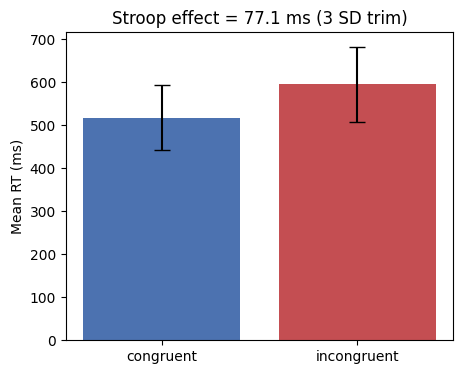

In [13]:
def analyse(df: pd.DataFrame, *, outlier_sd: float = 3.0) -> dict:
    """計算 Stroop effect。outlier_sd 為**分析參數**（可調），不是 cleaning 規則。"""
    # Distribution-based trim（Whelan 2008）：mean ± outlier_sd × SD
    mu, sd = df["rt_ms"].mean(), df["rt_ms"].std()
    mask = (df["rt_ms"] - mu).abs() <= outlier_sd * sd
    df_trim = df[mask]
    print(f"outlier trim ({outlier_sd} SD): {len(df)} -> {len(df_trim)} rows "
          f"(剔除 {len(df) - len(df_trim)})")

    by_cond = df_trim.groupby("condition")["rt_ms"].agg(["mean", "std", "count"])
    cong = by_cond.loc["congruent", "mean"]
    incong = by_cond.loc["incongruent", "mean"]
    stroop_effect = incong - cong
    return {
        "by_condition": by_cond,
        "stroop_effect_ms": stroop_effect,
        "n_used": len(df_trim),
    }


result = analyse(df_clean, outlier_sd=3.0)
print(result["by_condition"].round(1))
print(f"\nStroop effect = {result['stroop_effect_ms']:.1f} ms")
print("預期 ≈ +80 ms（A.0 來源1 生成器第54行注入；落於 MacLeod 1991 之 50–100 ms）")
print("→ 觀測值與預期一致，cleaning + analysis 流程驗證通過。")

# 敏感度檢查：分析參數不同 → effect 不同（佐證為何 outlier 屬於 analyse）
for sd in (2.0, 2.5, 3.0):
    r = analyse(df_clean, outlier_sd=sd)
    print(f"  outlier_sd={sd}: Stroop effect = {r['stroop_effect_ms']:.1f} ms "
          f"(n={r['n_used']})")

# 視覺化：condition × mean RT（含 SD error bar）
bc = result["by_condition"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(bc.index, bc["mean"], yerr=bc["std"], capsize=6,
       color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Mean RT (ms)")
ax.set_title(f"Stroop effect = {result['stroop_effect_ms']:.1f} ms (3 SD trim)")
plt.show()

**為什麼 `outlier_sd` 放在 `analyse()` 而不是 `clean()`？**

`clean()` 的工作是修「**資料錯誤**」——型別錯置、sentinel、拼字不一致、整列重複。這些是客觀錯的，不管做什麼分析都該移除，且結果唯一、不帶研究判斷。

`outlier_sd`（mean ± k·SD 修剪）則是「**分析決策**」：要不要修、用 2 還是 3 SD，是研究者對「什麼算極端反應」的主觀選擇，會直接改變結論——上面敏感度檢查可見 `outlier_sd=2.0` 時 Stroop effect ≈ 63 ms、`3.0` 時 ≈ 77 ms。把它寫進 `clean()` 等於把一個可辩論的分析假設偽裝成「資料清理」，並讓 cleaning 結果不再唯一、難以重現。

因此：把它做成 `analyse()` 的**具名參數**（`outlier_sd=3.0`），審稿者/TA 可一眼看到此選擇、可調整、可做敏感度分析；`clean()` 維持純粹且 deterministic。這就是 cleaning 與 analysis 的邊界。